In [2]:

#  Build Master Feature Table (Pandas only)
# One row per user, combining all 4 CSVs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# ── Load all 4 CSVs ──
df_users       = pd.read_csv('D:/customer_churn/data/users.csv')
df_txns        = pd.read_csv('D:/customer_churn/data/transactions.csv')
df_events      = pd.read_csv('D:/customer_churn/data/app_events.csv')
df_tickets     = pd.read_csv('D:/customer_churn/data/support_tickets.csv')

print(f"Users: {df_users.shape} | Transactions: {df_txns.shape} | "
      f"Events: {df_events.shape} | Tickets: {df_tickets.shape}")

# ── 1. Transaction features (only successful txns) ──
success_txns = df_txns[df_txns['status'] == 'success'].copy()
success_txns['txn_date'] = pd.to_datetime(success_txns['txn_date'])

txn_agg = success_txns.groupby('user_id').agg(
    txn_count       = ('txn_id', 'count'),
    total_spent     = ('amount', 'sum'),
    avg_txn_amount  = ('amount', 'mean'),
    last_txn_date   = ('txn_date', 'max')
).reset_index()

# days_since_last_txn = today - last_txn_date (in days)
now = pd.Timestamp.now()
txn_agg['days_since_last_txn'] = (now - txn_agg['last_txn_date']).dt.days
txn_agg = txn_agg.drop(columns='last_txn_date')

# ── 2. App event features (app_open events only) ──
app_opens = df_events[df_events['event_type'] == 'app_open'].copy()
app_opens['event_date'] = pd.to_datetime(app_opens['event_timestamp']).dt.date

events_agg = app_opens.groupby('user_id').agg(
    app_open_count = ('event_id', 'count'),
    active_days     = ('event_date', 'nunique')
).reset_index()

# ── 3. Support ticket features ──
tickets_agg = df_tickets.groupby('user_id').agg(
    ticket_count      = ('ticket_id', 'count'),
    avg_satisfaction  = ('satisfaction_score', 'mean')
).reset_index()

# ── 4. Merge everything onto the users table ──
df = df_users[['user_id', 'age', 'city', 'account_type',
                'account_balance', 'kyc_complete', 'churn']].copy()

df = df.merge(txn_agg,     on='user_id', how='left')
df = df.merge(events_agg,  on='user_id', how='left')
df = df.merge(tickets_agg, on='user_id', how='left')

# ── 5. Fill NaNs (users with no txns/events/tickets) ──
df['txn_count']           = df['txn_count'].fillna(0)
df['total_spent']         = df['total_spent'].fillna(0)
df['avg_txn_amount']      = df['avg_txn_amount'].fillna(0)
df['days_since_last_txn'] = df['days_since_last_txn'].fillna(999)
df['app_open_count']      = df['app_open_count'].fillna(0)
df['active_days']         = df['active_days'].fillna(0)
df['ticket_count']        = df['ticket_count'].fillna(0)
df['avg_satisfaction']    = df['avg_satisfaction'].fillna(0)

print(f"\n✅ Master feature table: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nChurn distribution:\n{df['churn'].value_counts()}")
df.head()

Users: (10000, 11) | Transactions: (144355, 6) | Events: (228416, 6) | Tickets: (3807, 8)

✅ Master feature table: 10,000 rows × 15 columns

Columns: ['user_id', 'age', 'city', 'account_type', 'account_balance', 'kyc_complete', 'churn', 'txn_count', 'total_spent', 'avg_txn_amount', 'days_since_last_txn', 'app_open_count', 'active_days', 'ticket_count', 'avg_satisfaction']

Churn distribution:
churn
0    9172
1     828
Name: count, dtype: int64


,user_id,age,city,account_type,account_balance,kyc_complete,churn,txn_count,total_spent,avg_txn_amount,days_since_last_txn,app_open_count,active_days,ticket_count,avg_satisfaction
0,USR00001,22,Bengaluru,savings,1579.99,True,0,8,13757.12,1719.640000,11,8,8,0.0,0.0
1,USR00002,37,Jaipur,wallet,311.99,True,0,9,11928.71,1325.412222,37,8,8,0.0,0.0
2,USR00003,29,Mumbai,savings,14187.85,True,0,9,15498.90,1722.100000,57,5,5,1.0,4.0
3,USR00004,29,Lucknow,savings,716.84,True,0,17,17322.58,1018.975294,17,7,7,0.0,0.0
4,USR00005,19,Mumbai,current,13462.57,True,0,18,26856.99,1492.055000,11,7,7,1.0,4.0


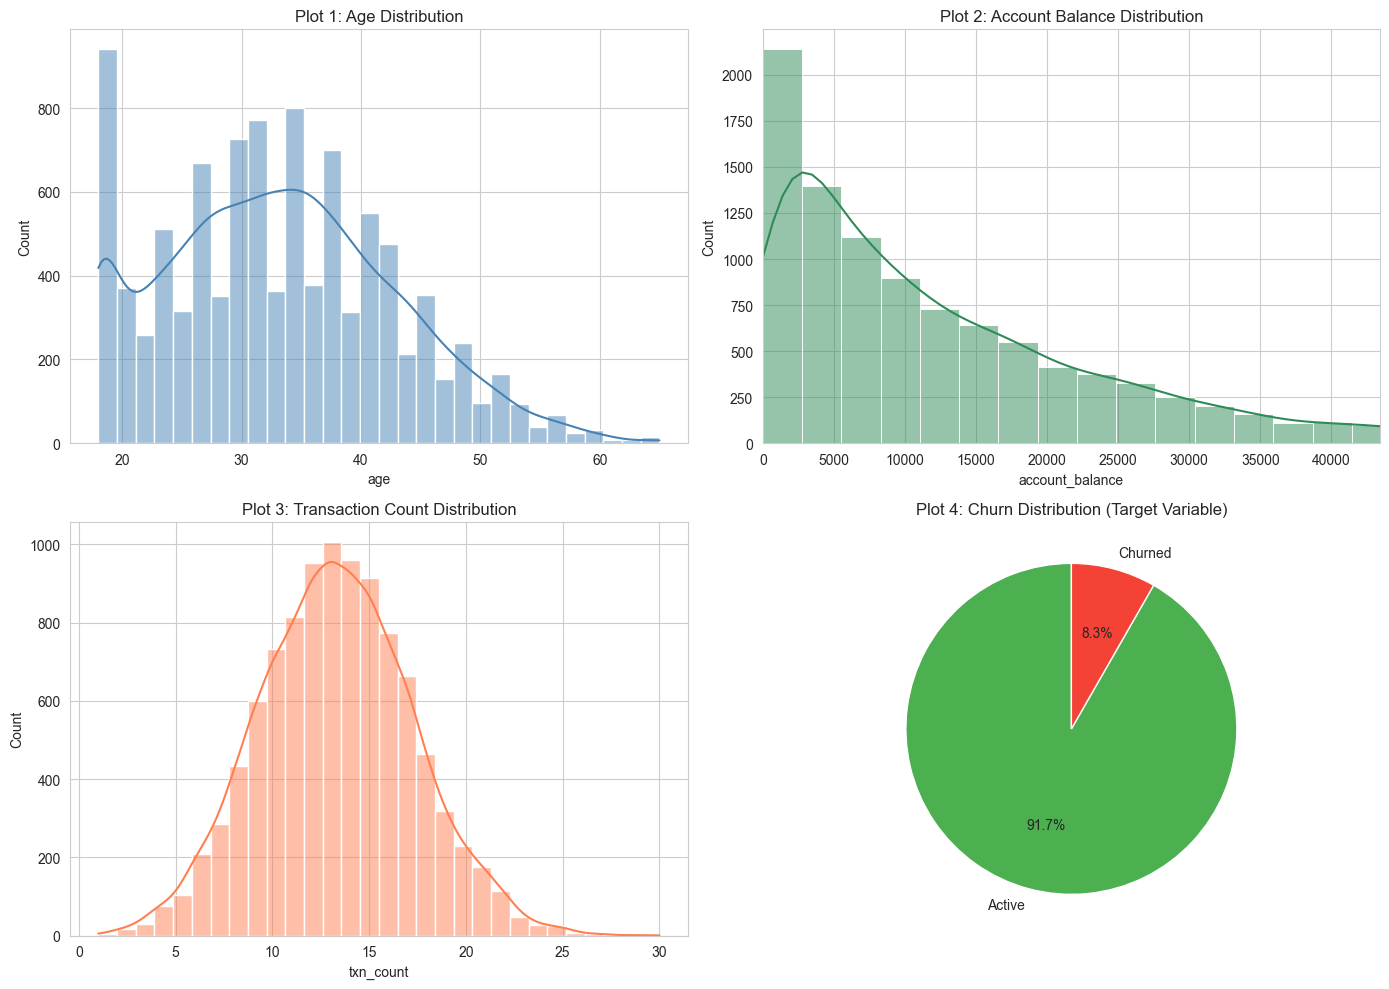

In [3]:

# — Univariate Distributions (Plots 1-4)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Age distribution
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Plot 1: Age Distribution')

# Plot 2: Account balance (log scale due to skew)
sns.histplot(df['account_balance'], bins=50, kde=True, ax=axes[0,1], color='seagreen')
axes[0,1].set_title('Plot 2: Account Balance Distribution')
axes[0,1].set_xlim(0, df['account_balance'].quantile(0.95))  # cut extreme outliers for readability

# Plot 3: Transaction count
sns.histplot(df['txn_count'], bins=30, kde=True, ax=axes[1,0], color='coral')
axes[1,0].set_title('Plot 3: Transaction Count Distribution')

# Plot 4: Churn distribution (the target variable!)
churn_counts = df['churn'].value_counts()
axes[1,1].pie(churn_counts, labels=['Active', 'Churned'], autopct='%1.1f%%',
               colors=['#4CAF50', '#F44336'], startangle=90)
axes[1,1].set_title('Plot 4: Churn Distribution (Target Variable)')

plt.tight_layout()
plt.show()

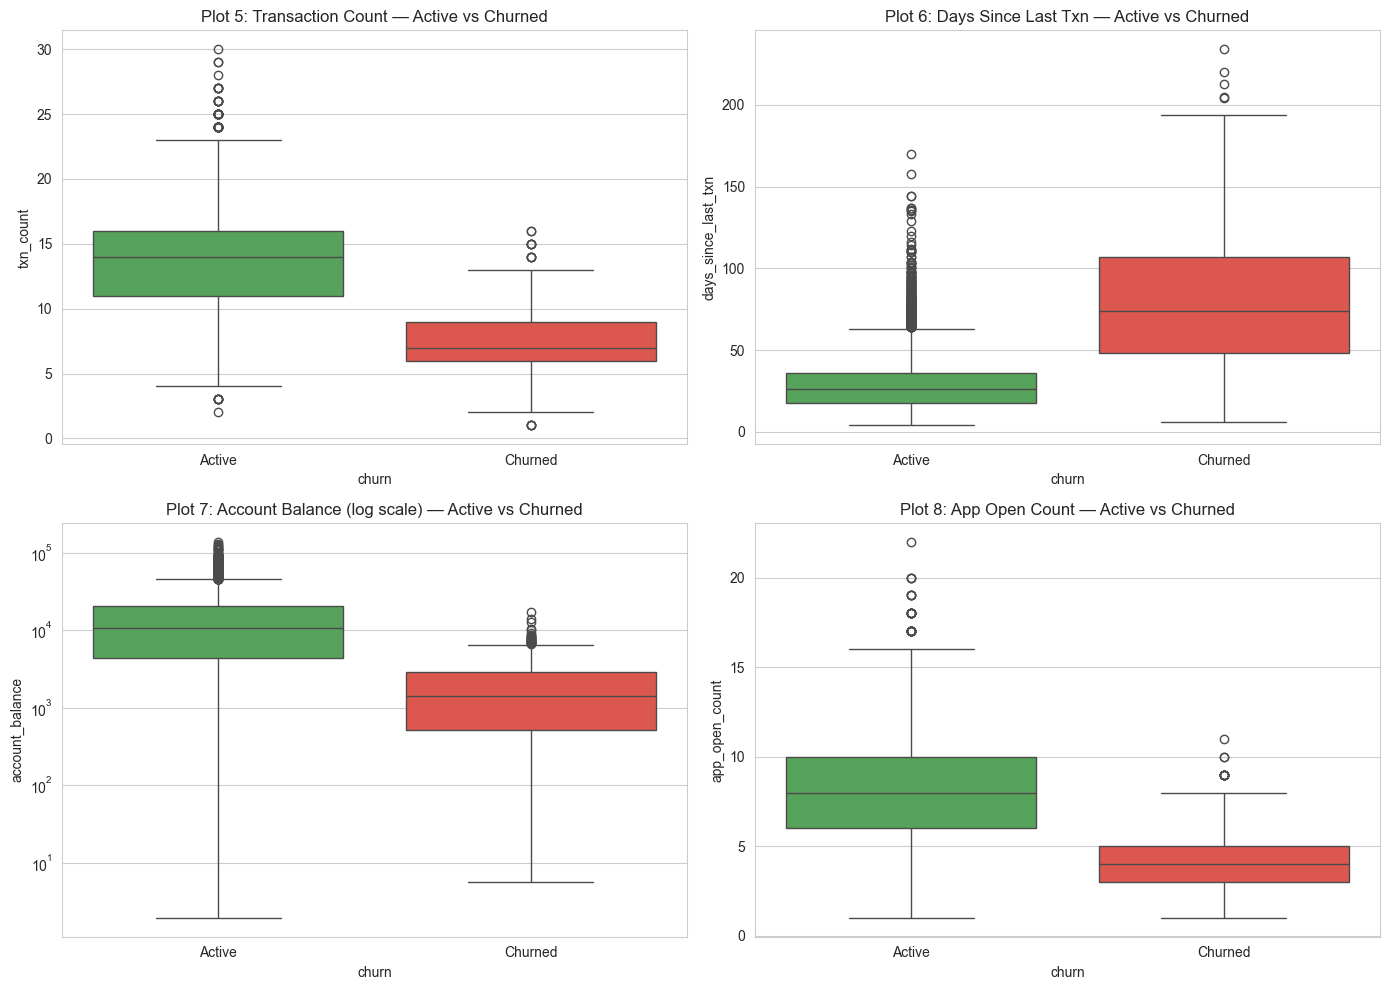

In [4]:

# — Churned vs Active Comparisons (Plots 5-8)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 5: Transaction count by churn
sns.boxplot(data=df, x='churn', y='txn_count', ax=axes[0,0], palette=['#4CAF50','#F44336'])
axes[0,0].set_title('Plot 5: Transaction Count — Active vs Churned')
axes[0,0].set_xticklabels(['Active', 'Churned'])

# Plot 6: Days since last transaction by churn
sns.boxplot(data=df, x='churn', y='days_since_last_txn', ax=axes[0,1], palette=['#4CAF50','#F44336'])
axes[0,1].set_title('Plot 6: Days Since Last Txn — Active vs Churned')
axes[0,1].set_xticklabels(['Active', 'Churned'])

# Plot 7: Account balance by churn (log scale)
sns.boxplot(data=df, x='churn', y='account_balance', ax=axes[1,0], palette=['#4CAF50','#F44336'])
axes[1,0].set_yscale('log')
axes[1,0].set_title('Plot 7: Account Balance (log scale) — Active vs Churned')
axes[1,0].set_xticklabels(['Active', 'Churned'])

# Plot 8: App opens by churn
sns.boxplot(data=df, x='churn', y='app_open_count', ax=axes[1,1], palette=['#4CAF50','#F44336'])
axes[1,1].set_title('Plot 8: App Open Count — Active vs Churned')
axes[1,1].set_xticklabels(['Active', 'Churned'])

plt.tight_layout()
plt.show()



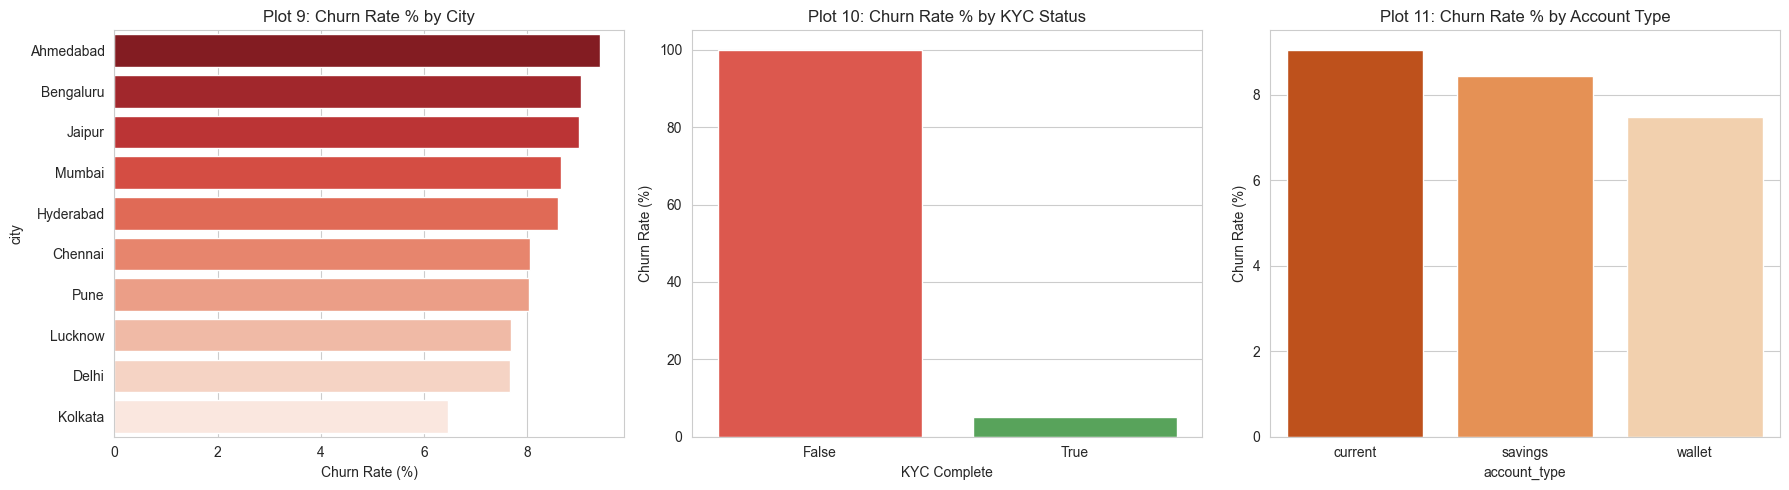

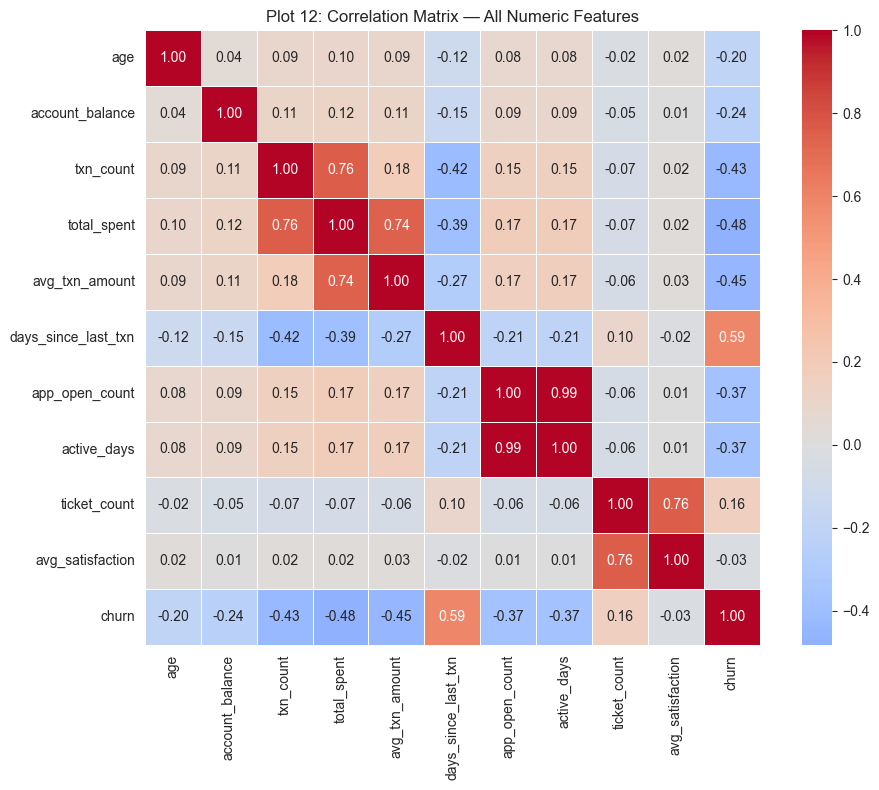

In [5]:

# — Categorical Analysis + Correlation (Plots 9-11)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 9: Churn rate by city
city_churn = df.groupby('city')['churn'].mean().sort_values(ascending=False) * 100
sns.barplot(x=city_churn.values, y=city_churn.index, ax=axes[0], palette='Reds_r')
axes[0].set_title('Plot 9: Churn Rate % by City')
axes[0].set_xlabel('Churn Rate (%)')

# Plot 10: Churn rate by KYC completion
kyc_churn = df.groupby('kyc_complete')['churn'].mean() * 100
sns.barplot(x=kyc_churn.index.astype(str), y=kyc_churn.values, ax=axes[1], palette=['#F44336','#4CAF50'])
axes[1].set_title('Plot 10: Churn Rate % by KYC Status')
axes[1].set_xlabel('KYC Complete')
axes[1].set_ylabel('Churn Rate (%)')

# Plot 11: Churn rate by account type
acct_churn = df.groupby('account_type')['churn'].mean().sort_values(ascending=False) * 100
sns.barplot(x=acct_churn.index, y=acct_churn.values, ax=axes[2], palette='Oranges_r')
axes[2].set_title('Plot 11: Churn Rate % by Account Type')
axes[2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

# Plot 12: Correlation heatmap (numeric features only)
numeric_cols = ['age', 'account_balance', 'txn_count', 'total_spent', 'avg_txn_amount',
                'days_since_last_txn', 'app_open_count', 'active_days',
                'ticket_count', 'avg_satisfaction', 'churn']

plt.figure(figsize=(10, 8))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Plot 12: Correlation Matrix — All Numeric Features')
plt.tight_layout()
plt.show()

